# Hierarchical Insect Classifier — Ablation Run B (No Focal on l4a)

> **Run B**: `LeafBranchFocalLoss` is removed from l4a. The head is trained with
> `CardinalityWeightedCELoss` only (weight fixed at 1.0). All other losses
> (sibling consistency, coherence, CE on every other head) are **unchanged**.

# Hierarchical Insect Classifier — Baseline (v15 CSV)

## CSV facts (hierarchical_labels_v15.csv)
| Property | Value |
|---|---|
| Total samples | 37,588 (train 28,466 / val 7,120 / test 2,002) |
| Species present | 1-3, 5-12, 14-18, 21-31 |
| l1_pest | 0=non-pest, 1=pest |
| l2_role | 0=predator, 1=non-predator, -1=masked |
| l3_pred_type | 0=ladybug-pred, 1=other-pred, -1=masked |
| l3_nonpred_type | 0=ladybug-nonpred, 1=other-nonpred, -1=masked |
| sp_pred_ladybug_common | 0-10 → sp1-3,5-12 (11 classes), -1=masked |
| sp_other_pred | 0-2 → sp14-16 (3 classes), -1=masked |
| sp_nonpred_ladybug | 0-1 → sp17-18 (2 classes), -1=masked |

## Hierarchy
```
level1 (pest/non-pest)
├── 0 → sp21 (non-pest, terminal)
└── 1 → level2 (predator role)
    ├── 0 (predator) → l3a (pred type)
    │   ├── 0 (ladybug-pred) → l4a: 11 classes → sp1,2,3,5,6,7,8,9,10,11,12
    │   └── 1 (other-pred)   → l4b:  3 classes → sp14,15,16
    └── 1 (non-predator) → l3b (nonpred type)
        ├── 0 (ladybug-nonpred) → l4c: 2 classes → sp17,18
        └── 1 (other-nonpred)   → sp22-31 (terminal, merged as sp22)
``\

In [1]:
!pip install timm scikit-learn pandas pillow tqdm -q

,
,[notice] A new release of pip is available: 24.2 -> 26.0.1
,[notice] To update, run: python -m pip install --upgrade pip


## 1. Dataset

In [2]:
# Cell 2 — Dataset
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms


class HierarchicalInsectDataset(Dataset):
    EXCLUDED_SPECIES = {4, 13, 19}

    def __init__(self, csv_file, split, img_size=224):
        self.df = pd.read_csv(csv_file)
        self.df = self.df[self.df["split"] == split].reset_index(drop=True)
        self.df = self.df[~self.df["species_id"].isin(self.EXCLUDED_SPECIES)].reset_index(drop=True)
        self.split = split

        # No augmentation — identical transform for all splits
        self.transform = transforms.Compose([
            transforms.Resize(int(img_size * 256 / 224)),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.transform(img)
        labels = {
            "level1":     torch.tensor(row["l1_pest"],                 dtype=torch.long),
            "level2":     torch.tensor(row["l2_role"],                 dtype=torch.long),
            "l3a":        torch.tensor(row["l3_pred_type"],            dtype=torch.long),
            "l3b":        torch.tensor(row["l3_nonpred_type"],         dtype=torch.long),
            "l4a":        torch.tensor(row["sp_pred_ladybug_common"],  dtype=torch.long),
            "l4b":        torch.tensor(row["sp_other_pred"],           dtype=torch.long),
            "l4c":        torch.tensor(row["sp_nonpred_ladybug"],      dtype=torch.long),
            "species_id": torch.tensor(row["species_id"],              dtype=torch.long),
        }
        return img, labels

## 2. Model

In [3]:
# Cell 3 — Model
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm


class StableAdapter(nn.Module):
    def __init__(self, dim, bottleneck=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, bottleneck),
            nn.LayerNorm(bottleneck),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(bottleneck, dim),
            nn.Dropout(dropout),
        )
        self.gate = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        return x + self.gate * self.net(x)


class EfficientNetHierarchicalV5(nn.Module):
    def __init__(self, backbone="efficientnet_b0", pretrained=True, feat_dim=512):
        super().__init__()

        self.backbone = timm.create_model(
            backbone,
            pretrained=pretrained,
            num_classes=0,
            drop_rate=0.2,
            drop_path_rate=0.3,
        )
        in_features = self.backbone.num_features  # 1280 for B0

        self.shared = nn.Sequential(
            nn.Linear(in_features, feat_dim),
            nn.LayerNorm(feat_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
        )
        for layer in self.shared:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

        self.adapt_l1  = StableAdapter(feat_dim)
        self.adapt_l2  = StableAdapter(feat_dim)
        self.adapt_l3a = StableAdapter(feat_dim)
        self.adapt_l3b = StableAdapter(feat_dim)
        self.adapt_l4b = StableAdapter(feat_dim)
        self.adapt_l4c = StableAdapter(feat_dim)
        self.adapt_l4a = StableAdapter(feat_dim, bottleneck=128, dropout=0.4)

        self.head_level1 = nn.Linear(feat_dim, 2)
        self.head_level2 = nn.Linear(feat_dim, 2)
        self.head_l3a    = nn.Linear(feat_dim, 2)
        self.head_l3b    = nn.Linear(feat_dim, 2)
        self.head_l4a    = nn.Linear(feat_dim, 12)
        self.head_l4b    = nn.Linear(feat_dim, 3)
        self.head_l4c    = nn.Linear(feat_dim, 2)

        for head in [self.head_level1, self.head_level2, self.head_l3a,
                     self.head_l3b, self.head_l4a, self.head_l4b, self.head_l4c]:
            nn.init.xavier_normal_(head.weight)
            nn.init.zeros_(head.bias)

    def forward(self, x, targets=None):
        feats = self.shared(self.backbone(x))
        outputs = {}
        outputs["level1"] = self.head_level1(self.adapt_l1(feats))
        outputs["level2"] = self.head_level2(self.adapt_l2(feats))
        outputs["l3a"]    = self.head_l3a(self.adapt_l3a(feats))
        outputs["l3b"]    = self.head_l3b(self.adapt_l3b(feats))
        outputs["l4a"]    = self.head_l4a(self.adapt_l4a(feats))
        outputs["l4b"]    = self.head_l4b(self.adapt_l4b(feats))
        outputs["l4c"]    = self.head_l4c(self.adapt_l4c(feats))
        return outputs

## 3. Loss

In [4]:
# Cell 4 — Loss  |  Ablation Run B: NO LeafBranchFocalLoss on l4a
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np


class LeafSiblingConsistencyLoss(nn.Module):
    def __init__(self, weight=0.05, similarity_threshold=0.7):
        super().__init__()
        self.weight = weight
        self.similarity_threshold = similarity_threshold

    def forward(self, leaf_logits, sibling_mask=None):
        probs = F.softmax(leaf_logits, dim=1)
        if sibling_mask is None:
            entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1)
            return self.weight * entropy.mean()
        batch_size = probs.size(0)
        probs_expanded1 = probs.unsqueeze(2)
        probs_expanded2 = probs.unsqueeze(1)
        diff = torch.abs(probs_expanded1 - probs_expanded2)
        sibling_mask = sibling_mask.unsqueeze(0).expand(batch_size, -1, -1)
        sibling_diff = diff * sibling_mask
        loss = F.relu(sibling_diff - self.similarity_threshold).mean()
        return self.weight * loss


class StableClassBalancedFocalLoss(nn.Module):
    def __init__(self, samples_per_class, beta=0.999, gamma_minor=2.0,
                 gamma_major=0.5, ignore_index=-1):
        super().__init__()
        samples_per_class = torch.tensor(samples_per_class, dtype=torch.float)
        effective_num = 1.0 - torch.pow(beta, samples_per_class)
        effective_num = torch.clamp(effective_num, min=1e-8)
        weights = (1.0 - beta) / effective_num
        weights = weights / weights.sum()
        self.register_buffer("alpha", weights)
        self.gamma_minor = gamma_minor
        self.gamma_major = gamma_major
        self.ignore_index = ignore_index
        self.eps = 1e-8

    def forward(self, logits, targets):
        valid = targets != self.ignore_index
        if valid.sum() == 0:
            return torch.tensor(0.0, device=logits.device, requires_grad=True)
        logits = logits[valid]
        targets = targets[valid]
        log_probs = F.log_softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes=logits.size(1)).float()
        pt = torch.clamp((torch.exp(log_probs) * targets_one_hot).sum(dim=1),
                         min=self.eps, max=1.0 - self.eps)
        gamma = torch.where(targets == 1,
                            torch.full_like(pt, self.gamma_minor),
                            torch.full_like(pt, self.gamma_major))
        alpha = self.alpha.to(targets.device)[targets]
        return (-alpha * (1.0 - pt) ** gamma * torch.log(pt)).mean()


class CardinalityWeightedCELoss(nn.Module):
    def __init__(self, num_classes, ignore_index=-1, label_smoothing=0.1):
        super().__init__()
        self.scale = 1.0 / (num_classes ** 0.5)
        self.ce = nn.CrossEntropyLoss(ignore_index=ignore_index,
                                      label_smoothing=label_smoothing)

    def forward(self, logits, targets):
        return self.scale * self.ce(logits, targets)


class HierarchicalCoherenceLoss(nn.Module):
    def __init__(self, weight=0.1, ignore_index=-1):
        super().__init__()
        self.weight = weight
        self.ignore_index = ignore_index
        self.eps = 1e-8

    def forward(self, child_logits, parent_logits, child_targets, parent_targets):
        valid = (child_targets != self.ignore_index) & (parent_targets != self.ignore_index)
        if valid.sum() == 0:
            return torch.tensor(0.0, device=child_logits.device, requires_grad=True)
        child_logits  = torch.clamp(child_logits[valid],  min=-10.0, max=10.0)
        parent_logits = torch.clamp(parent_logits[valid], min=-10.0, max=10.0)
        child_prob  = torch.clamp(F.softmax(child_logits,  dim=1).max(dim=1)[0],
                                  min=self.eps, max=1.0 - self.eps)
        parent_prob = torch.clamp(F.softmax(parent_logits, dim=1).max(dim=1)[0],
                                  min=self.eps, max=1.0 - self.eps)
        violation = F.relu(child_prob - parent_prob)
        return self.weight * (violation ** 2).mean()


class HierarchicalMultiTaskLoss(nn.Module):
    """Run B: loss_l4a_focal removed. l4a trained with CE only (weight=1.0 fixed)."""
    def __init__(self, level1_samples, lambda_coherence=0.1,
                 leaf_lambda=0.3, use_leaf_consistency=True):
        super().__init__()

        self.loss_level1 = StableClassBalancedFocalLoss(level1_samples)
        self.loss_level2 = CardinalityWeightedCELoss(2,  label_smoothing=0.1)
        self.loss_l3a    = CardinalityWeightedCELoss(2,  label_smoothing=0.1)
        self.loss_l3b    = CardinalityWeightedCELoss(2,  label_smoothing=0.1)
        self.loss_l4a_ce = CardinalityWeightedCELoss(12, label_smoothing=0.1)
        # ── Run B: loss_l4a_focal intentionally removed ──
        self.loss_l4b    = CardinalityWeightedCELoss(3,  label_smoothing=0.1)
        self.loss_l4c    = CardinalityWeightedCELoss(2,  label_smoothing=0.1)

        self.use_leaf_consistency = use_leaf_consistency
        if use_leaf_consistency:
            self.leaf_consistency = LeafSiblingConsistencyLoss(weight=0.05)

        self.coherence = HierarchicalCoherenceLoss(weight=lambda_coherence)

        self.task_weights = {
            "level1": 1.0,
            "level2": 0.8,
            "l3a":    0.6,
            "l3b":    0.6,
            "l4a_ce": 1.0,   # boosted to 1.0 — compensates for removed focal
            "l4b":    0.4,
            "l4c":    0.4,
        }
        self.leaf_lambda = leaf_lambda

    def forward(self, outputs, targets, sibling_mask=None):
        device = next(iter(outputs.values())).device
        total_loss = torch.tensor(0.0, device=device, requires_grad=True)
        loss_components = {}

        l1_loss = self.loss_level1(outputs["level1"], targets["level1"])
        if torch.isfinite(l1_loss):
            total_loss = total_loss + self.task_weights["level1"] * l1_loss
            loss_components["l1"] = l1_loss.item()

        non_pest = targets["level1"] == 0

        def gate(t):
            t = t.clone()
            t[non_pest] = -1
            return t

        t2  = gate(targets["level2"])
        t3a = gate(targets["l3a"])
        t3b = gate(targets["l3b"])
        t4a = gate(targets["l4a"])
        t4b = gate(targets["l4b"])
        t4c = gate(targets["l4c"])

        losses = [
            ("level2", self.loss_level2(outputs["level2"], t2)),
            ("l3a",    self.loss_l3a(outputs["l3a"], t3a)),
            ("l3b",    self.loss_l3b(outputs["l3b"], t3b)),
            ("l4a_ce", self.loss_l4a_ce(outputs["l4a"], t4a)),
            # ── Run B: l4a_focal entry removed ──
            ("l4b",    self.loss_l4b(outputs["l4b"], t4b)),
            ("l4c",    self.loss_l4c(outputs["l4c"], t4c)),
        ]

        for task_name, loss_val in losses:
            if torch.isfinite(loss_val):
                total_loss = total_loss + self.task_weights[task_name] * loss_val
                loss_components[task_name] = loss_val.item()

        if self.use_leaf_consistency and "l4a" in outputs:
            lc = self.leaf_consistency(outputs["l4a"], sibling_mask)
            if torch.isfinite(lc):
                total_loss = total_loss + lc
                loss_components["leaf_consistency"] = lc.item()

        coherence_losses = [
            ("coh_l3a_level2", self.coherence(outputs["l3a"], outputs["level2"], t3a, t2)),
            ("coh_l3b_level2", self.coherence(outputs["l3b"], outputs["level2"], t3b, t2)),
            ("coh_l4a_l3a",   self.coherence(outputs["l4a"], outputs["l3a"],    t4a, t3a)),
            ("coh_l4c_l3b",   self.coherence(outputs["l4c"], outputs["l3b"],    t4c, t3b)),
        ]
        for coh_name, coh_loss in coherence_losses:
            if torch.isfinite(coh_loss):
                total_loss = total_loss + coh_loss
                loss_components[coh_name] = coh_loss.item()

        if not torch.isfinite(total_loss):
            return torch.tensor(0.0, device=device, requires_grad=True), loss_components

        return total_loss, loss_components

    def get_leaf_accuracy_weights(self, current_epoch, total_epochs):
        # Run B: no focal to schedule — l4a_ce stays fixed at 1.0
        pass


def create_ladybug_sibling_mask():
    num_classes = 12
    mask = torch.zeros(num_classes, num_classes)
    groups = [[0, 1, 2], [3, 4, 5], [6, 7, 8], [9, 10], [11]]
    for group in groups:
        for i in group:
            for j in group:
                if i != j:
                    mask[i, j] = 1.0
    return mask


## 4. Helper: decode outputs → species_id

Mapping derived directly from v15 CSV:

| Head | Class | Species ID |
|---|---|---|
| level1==0 | — | 21 |
| l4a | 0 | 1 |
| l4a | 1 | 2 |
| l4a | 2 | 3 |
| l4a | 3 | 5 |
| l4a | 4 | 6 |
| l4a | 5 | 7 |
| l4a | 6 | 8 |
| l4a | 7 | 9 |
| l4a | 8 | 10 |
| l4a | 9 | 11 |
| l4a | 10 | 12 |
| l4b | 0 | 14 |
| l4b | 1 | 15 |
| l4b | 2 | 16 |
| l4c | 0 | 17 |
| l4c | 1 | 18 |
| level2==1 + l3b==1 | — | 22 (merged 22-31) |

## 5. Training

In [5]:
# Cell 5 — Training
import os
import torch
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm
from collections import defaultdict
import pandas as pd

# ===================== CONFIG =====================
CSV_PATH     = "/workspace/hierarchical_labels_v15.csv"
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS       = 70
LR           = 1.5e-4
LR_L4A       = LR * 0.5
NUM_WORKERS  = 10
PATIENCE     = 8
WEIGHT_DECAY = 3e-4

DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_DIR = "/workspace/ablation_runB_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

print("🔥 DEVICE:", DEVICE)
print("📋 Ablation Run B — No Focal on l4a (CE-only)")

# ===================== DATA =====================
df = pd.read_csv(CSV_PATH)

train_ds = HierarchicalInsectDataset(CSV_PATH, split="train", img_size=IMG_SIZE)
val_ds   = HierarchicalInsectDataset(CSV_PATH, split="val",   img_size=IMG_SIZE)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,}")

all_species_ids = sorted(set(
    22 if 22 <= int(s) <= 31 else int(s)
    for s in df["species_id"].unique()
    if int(s) not in {4, 13, 19}
))

# ===================== MODEL =====================
model = EfficientNetHierarchicalV5(
    backbone="efficientnet_b0", pretrained=True, feat_dim=512
).to(DEVICE)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ===================== LOSS =====================
l1_counts = train_ds.df["l1_pest"].value_counts().sort_index().values.tolist()
criterion = HierarchicalMultiTaskLoss(level1_samples=l1_counts, lambda_coherence=0.1)
sibling_mask = create_ladybug_sibling_mask().to(DEVICE)

# ===================== OPTIMIZER =====================
l4a_params    = list(model.adapt_l4a.parameters()) + list(model.head_l4a.parameters())
l4a_param_ids = set(id(p) for p in l4a_params)
other_params  = [p for p in model.parameters() if id(p) not in l4a_param_ids]

optimizer = optim.AdamW(
    [
        {"params": other_params, "lr": LR},
        {"params": l4a_params,   "lr": LR_L4A, "weight_decay": WEIGHT_DECAY * 2},
    ],
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
    eps=1e-8,
)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LR, LR_L4A],
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.15,
    anneal_strategy="cos",
)

use_amp = DEVICE == "cuda"
scaler  = torch.amp.GradScaler("cuda", enabled=use_amp) if use_amp else None

# ===================== HELPERS =====================
def predict_species_id(outputs):
    device = outputs["level1"].device
    B = outputs["level1"].shape[0]
    preds = torch.full((B,), fill_value=-1, dtype=torch.long, device=device)
    l1  = outputs["level1"].argmax(1)
    l2  = outputs["level2"].argmax(1)
    l3a = outputs["l3a"].argmax(1)
    l3b = outputs["l3b"].argmax(1)
    l4a = outputs["l4a"].argmax(1)
    l4b = outputs["l4b"].argmax(1)
    l4c = outputs["l4c"].argmax(1)
    preds[l1 == 0] = 21
    m_low  = (l1 == 1) & (l2 == 0) & (l3a == 0) & (l4a <= 2)
    preds[m_low]  = l4a[m_low] + 1
    m_high = (l1 == 1) & (l2 == 0) & (l3a == 0) & (l4a >= 3) & (l4a <= 8)
    preds[m_high] = l4a[m_high] + 2
    m_sp11 = (l1 == 1) & (l2 == 0) & (l3a == 0) & (l4a == 9)
    preds[m_sp11] = 11
    m_sp12 = (l1 == 1) & (l2 == 0) & (l3a == 0) & (l4a == 10)
    preds[m_sp12] = 12
    m = (l1 == 1) & (l2 == 0) & (l3a == 1)
    preds[m] = l4b[m] + 14
    m = (l1 == 1) & (l2 == 1) & (l3b == 0)
    preds[m] = l4c[m] + 17
    m = (l1 == 1) & (l2 == 1) & (l3b == 1)
    preds[m] = 22
    return preds


def masked_accuracy(logits, targets):
    mask = targets != -1
    if mask.sum() == 0:
        return None
    with torch.no_grad():
        preds = logits.argmax(dim=1)
        return (preds[mask] == targets[mask]).float().mean().item()


def merge_sp(sid):
    return 22 if 22 <= int(sid) <= 31 else int(sid)

# ===================== TRAINING LOOP =====================
best_val_acc     = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{EPOCHS}  |  LR: {optimizer.param_groups[0]['lr']:.2e}")
    print(f"{'='*60}")

    criterion.get_leaf_accuracy_weights(epoch, EPOCHS)

    # ---- TRAIN ----
    model.train()
    train_loss = 0.0
    train_accs = defaultdict(list)
    tr_correct = tr_total = 0

    for images, labels in tqdm(train_loader, desc="TRAIN", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = {k: v.to(DEVICE, non_blocking=True) for k, v in labels.items()}

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(images)
            total_loss, loss_components = criterion(outputs, labels, sibling_mask)

        if use_amp:
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()
        train_loss += total_loss.item()

        for head in outputs:
            if head in labels:
                acc = masked_accuracy(outputs[head], labels[head])
                if acc is not None:
                    train_accs[head].append(acc)

        with torch.no_grad():
            sp_pred = predict_species_id(outputs)
            sp_tgt  = labels["species_id"]
            sp_pred_m = torch.tensor([merge_sp(s) for s in sp_pred.cpu().tolist()], device=DEVICE)
            sp_tgt_m  = torch.tensor([merge_sp(s) for s in sp_tgt.cpu().tolist()],  device=DEVICE)
            tr_correct += (sp_pred_m == sp_tgt_m).sum().item()
            tr_total   += sp_tgt.size(0)

    # ---- VALIDATE ----
    model.eval()
    val_loss = 0.0
    val_accs = defaultdict(list)
    va_correct = va_total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="VALID", leave=False):
            images = images.to(DEVICE, non_blocking=True)
            labels = {k: v.to(DEVICE, non_blocking=True) for k, v in labels.items()}

            outputs = model(images)
            total_loss, _ = criterion(outputs, labels, sibling_mask)
            val_loss += total_loss.item()

            for head in outputs:
                if head in labels:
                    acc = masked_accuracy(outputs[head], labels[head])
                    if acc is not None:
                        val_accs[head].append(acc)

            sp_pred = predict_species_id(outputs)
            sp_tgt  = labels["species_id"]
            sp_pred_m = torch.tensor([merge_sp(s) for s in sp_pred.cpu().tolist()], device=DEVICE)
            sp_tgt_m  = torch.tensor([merge_sp(s) for s in sp_tgt.cpu().tolist()],  device=DEVICE)
            va_correct += (sp_pred_m == sp_tgt_m).sum().item()
            va_total   += sp_tgt.size(0)

    # ---- REPORT ----
    avg_tr_loss = train_loss / len(train_loader)
    avg_va_loss = val_loss   / len(val_loader)
    tr_sp_acc   = tr_correct / tr_total if tr_total else 0
    va_sp_acc   = va_correct / va_total if va_total else 0

    print(f"  Train Loss: {avg_tr_loss:.4f}  |  Val Loss: {avg_va_loss:.4f}")
    print(f"  Train Species Acc: {tr_sp_acc:.4f}  |  Val Species Acc: {va_sp_acc:.4f}")
    print(f"  Per-head accuracies (val):")
    for head in sorted(val_accs):
        t = np.mean(train_accs[head]) if train_accs[head] else 0.0
        v = np.mean(val_accs[head])   if val_accs[head]   else 0.0
        print(f"    {head:<10} | train {t:.4f}  val {v:.4f}  gap {t-v:+.4f}")

    # ---- CHECKPOINT ----
    if va_sp_acc > best_val_acc:
        best_val_acc     = va_sp_acc
        patience_counter = 0
        torch.save({
            "epoch":            epoch,
            "model_state_dict": model.state_dict(),
            "val_species_acc":  va_sp_acc,
            "val_loss":         avg_va_loss,
        }, os.path.join(SAVE_DIR, "best_model.pth"))
        print(f"  ✅ Saved best model (val species acc: {va_sp_acc:.4f})")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print("\n🛑 Early stopping triggered.")
            break

print(f"\n🏆 Done. Best val species accuracy: {best_val_acc:.4f}")

🔥 DEVICE: cuda
,📋 Ablation Run B — No Focal on l4a (CE-only)
,Train: 28,466 | Val: 7,120
,Trainable params: 5,206,684
,
,============================================================
,Epoch 1/70  |  LR: 6.00e-06
,============================================================


TRAIN:   0%|          | 0/889 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:216: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
,  warnings.warn(


  Train Loss: 2.2136  |  Val Loss: 0.8547
,  Train Species Acc: 0.1348  |  Val Species Acc: 0.3396
,  Per-head accuracies (val):
,    l3a        | train 0.6743  val 0.8663  gap -0.1919
,    l3b        | train 0.7114  val 0.8656  gap -0.1542
,    l4a        | train 0.1203  val 0.2378  gap -0.1175
,    l4b        | train 0.4793  val 0.7636  gap -0.2843
,    l4c        | train 0.6462  val 0.8136  gap -0.1674
,    level1     | train 0.8456  val 0.9651  gap -0.1195
,    level2     | train 0.7467  val 0.8122  gap -0.0655
,  ✅ Saved best model (val species acc: 0.3396)
,
,============================================================
,Epoch 2/70  |  LR: 9.20e-06
,============================================================


  Train Loss: 1.6322  |  Val Loss: 0.6534
,  Train Species Acc: 0.3507  |  Val Species Acc: 0.5959
,  Per-head accuracies (val):
,    l3a        | train 0.8489  val 0.9315  gap -0.0825
,    l3b        | train 0.8651  val 0.9349  gap -0.0697
,    l4a        | train 0.2699  val 0.5352  gap -0.2653
,    l4b        | train 0.7562  val 0.8910  gap -0.1348
,    l4c        | train 0.8040  val 0.9077  gap -0.1037
,    level1     | train 0.9609  val 0.9836  gap -0.0227
,    level2     | train 0.8096  val 0.8764  gap -0.0668
,  ✅ Saved best model (val species acc: 0.5959)
,
,============================================================
,Epoch 3/70  |  LR: 1.85e-05
,============================================================


  Train Loss: 1.2648  |  Val Loss: 0.5434
,  Train Species Acc: 0.5542  |  Val Species Acc: 0.7268
,  Per-head accuracies (val):
,    l3a        | train 0.9087  val 0.9545  gap -0.0458
,    l3b        | train 0.9324  val 0.9697  gap -0.0373
,    l4a        | train 0.5118  val 0.6989  gap -0.1872
,    l4b        | train 0.8667  val 0.9382  gap -0.0716
,    l4c        | train 0.8842  val 0.9313  gap -0.0471
,    level1     | train 0.9805  val 0.9903  gap -0.0098
,    level2     | train 0.8589  val 0.9126  gap -0.0536
,  ✅ Saved best model (val species acc: 0.7268)
,
,============================================================
,Epoch 4/70  |  LR: 3.31e-05
,============================================================


...

  Train Loss: 0.5532  |  Val Loss: 0.3774
,  Train Species Acc: 0.9996  |  Val Species Acc: 0.9243
,  Per-head accuracies (val):
,    l3a        | train 1.0000  val 0.9916  gap +0.0084
,    l3b        | train 1.0000  val 0.9909  gap +0.0091
,    l4a        | train 0.9997  val 0.9166  gap +0.0832
,    l4b        | train 1.0000  val 0.9782  gap +0.0218
,    l4c        | train 1.0000  val 0.9743  gap +0.0257
,    level1     | train 1.0000  val 0.9989  gap +0.0011
,    level2     | train 0.9997  val 0.9735  gap +0.0262
,  ⏳ No improvement (4/8)
,
,============================================================
,Epoch 60/70  |  LR: 1.23e-05
,============================================================


  Train Loss: 0.5538  |  Val Loss: 0.3774
,  Train Species Acc: 0.9995  |  Val Species Acc: 0.9237
,  Per-head accuracies (val):
,    l3a        | train 0.9999  val 0.9905  gap +0.0094
,    l3b        | train 1.0000  val 0.9909  gap +0.0091
,    l4a        | train 0.9996  val 0.9138  gap +0.0858
,    l4b        | train 0.9998  val 0.9773  gap +0.0226
,    l4c        | train 0.9996  val 0.9743  gap +0.0253
,    level1     | train 0.9999  val 0.9987  gap +0.0012
,    level2     | train 0.9999  val 0.9731  gap +0.0268
,  ⏳ No improvement (5/8)
,
,============================================================
,Epoch 61/70  |  LR: 1.02e-05
,============================================================


  Train Loss: 0.5544  |  Val Loss: 0.3763
,  Train Species Acc: 0.9993  |  Val Species Acc: 0.9244
,  Per-head accuracies (val):
,    l3a        | train 0.9999  val 0.9907  gap +0.0092
,    l3b        | train 0.9997  val 0.9922  gap +0.0075
,    l4a        | train 0.9993  val 0.9164  gap +0.0829
,    l4b        | train 0.9999  val 0.9773  gap +0.0226
,    l4c        | train 0.9992  val 0.9779  gap +0.0212
,    level1     | train 1.0000  val 0.9987  gap +0.0012
,    level2     | train 1.0000  val 0.9735  gap +0.0264
,  ⏳ No improvement (6/8)
,
,============================================================
,Epoch 62/70  |  LR: 8.31e-06
,============================================================


  Train Loss: 0.5544  |  Val Loss: 0.3776
,  Train Species Acc: 0.9995  |  Val Species Acc: 0.9239
,  Per-head accuracies (val):
,    l3a        | train 1.0000  val 0.9912  gap +0.0087
,    l3b        | train 1.0000  val 0.9909  gap +0.0091
,    l4a        | train 0.9995  val 0.9160  gap +0.0835
,    l4b        | train 0.9999  val 0.9787  gap +0.0212
,    l4c        | train 0.9997  val 0.9743  gap +0.0254
,    level1     | train 1.0000  val 0.9985  gap +0.0015
,    level2     | train 0.9998  val 0.9722  gap +0.0275
,  ⏳ No improvement (7/8)
,
,============================================================
,Epoch 63/70  |  LR: 6.59e-06
,============================================================


  Train Loss: 0.5533  |  Val Loss: 0.3770
,  Train Species Acc: 0.9996  |  Val Species Acc: 0.9258
,  Per-head accuracies (val):
,    l3a        | train 0.9998  val 0.9914  gap +0.0084
,    l3b        | train 1.0000  val 0.9909  gap +0.0091
,    l4a        | train 0.9999  val 0.9155  gap +0.0844
,    l4b        | train 1.0000  val 0.9782  gap +0.0218
,    l4c        | train 0.9996  val 0.9761  gap +0.0235
,    level1     | train 1.0000  val 0.9989  gap +0.0011
,    level2     | train 0.9999  val 0.9730  gap +0.0269
,  ⏳ No improvement (8/8)
,
,🛑 Early stopping triggered.
,
,🏆 Done. Best val species accuracy: 0.9272


## 6. Evaluation (Test Split)

Loaded epoch 55  (saved val acc: 0.9272)


TEST: 100%|██████████| 63/63 [00:23<00:00,  2.66it/s]



,================================================================================
,TEST RESULTS — per species
,================================================================================
,Species              Acc  Precision   Recall       F1   Correct   Total
,--------------------------------------------------------------------------------
,sp1               0.8687     0.8866   0.8687   0.8776        86      99
,sp2               0.8824     0.8696   0.8824   0.8759        60      68
,sp3               0.9589     0.9091   0.9589   0.9333        70      73
,sp5               0.7895     0.9524   0.7895   0.8633        60      76
,sp6               0.8101     0.7529   0.8101   0.7805        64      79
,sp7               0.9079     0.8415   0.9079   0.8734        69      76
,sp8               0.8594     0.8871   0.8594   0.8730        55      64
,sp9               0.8088     0.9167   0.8088   0.8594        55      68
,sp10              0.8462     0.9322   0.8462   0.8871        55    

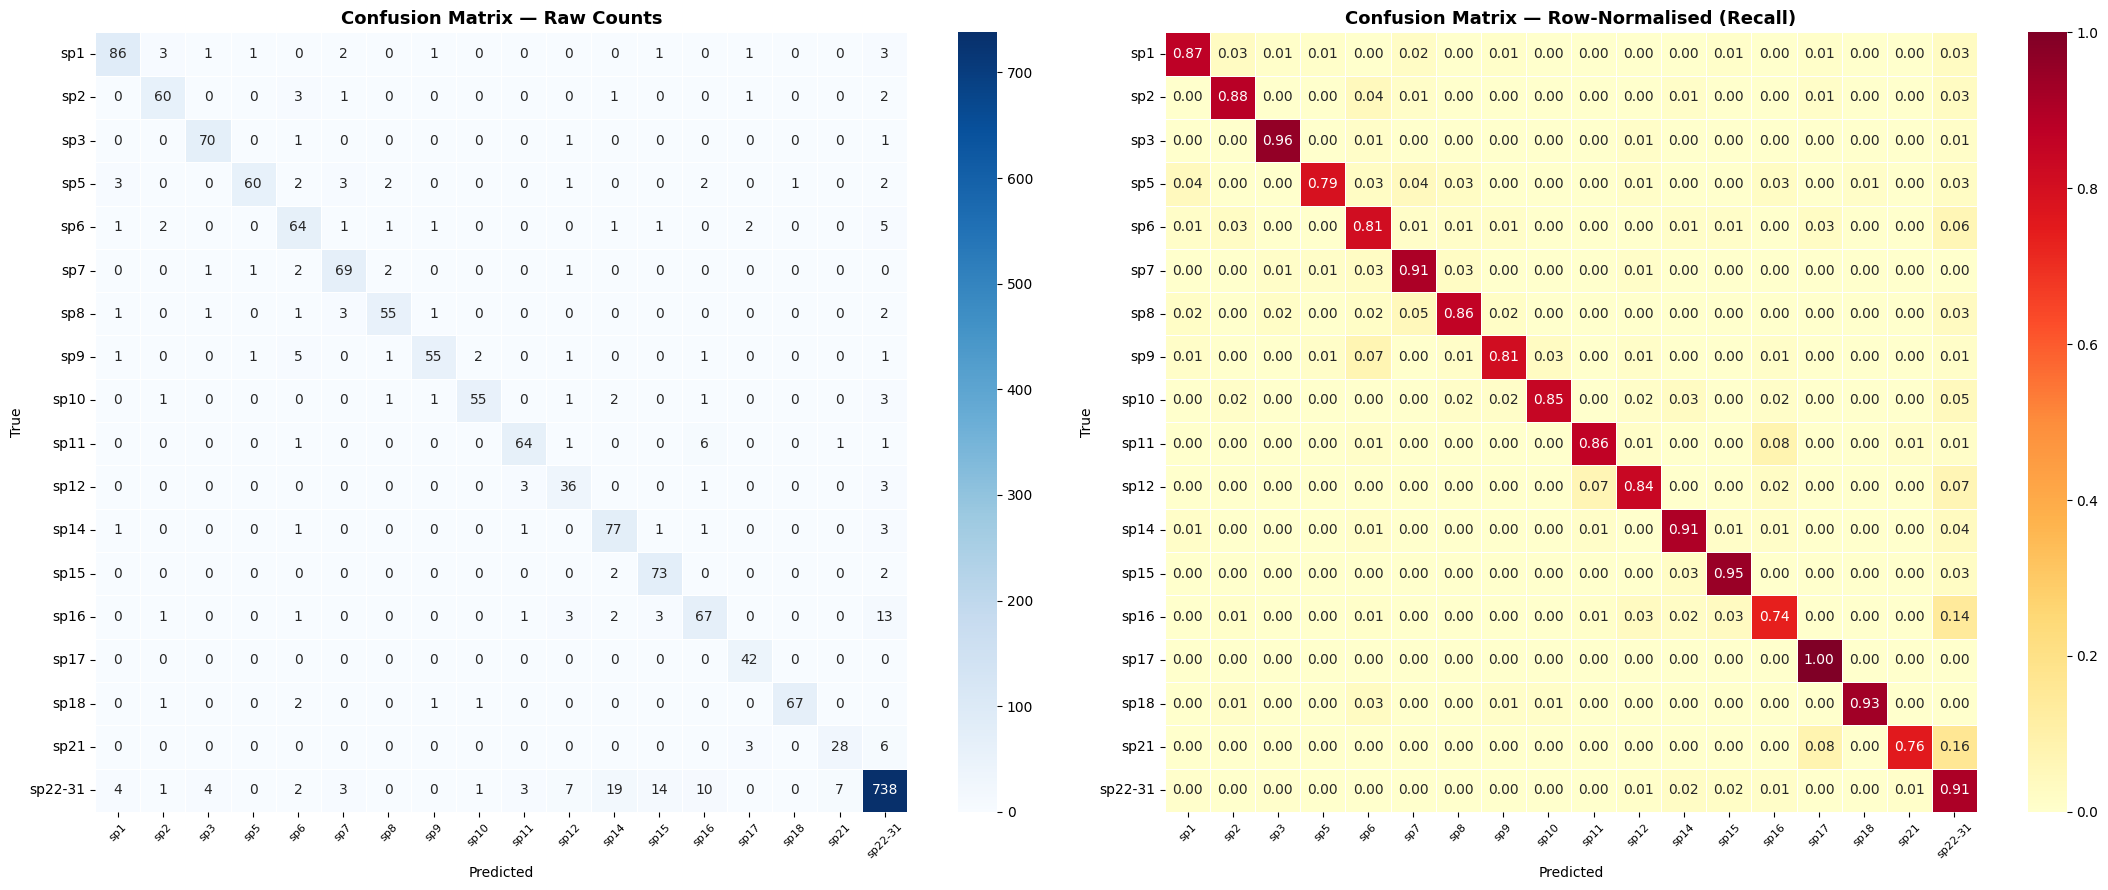

In [6]:
# Cell 6 — Evaluation (Test Split)
import torch
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef,
    balanced_accuracy_score,
)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

CHECKPOINT_PATH = "/workspace/ablation_runB_checkpoints/best_model.pth"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SPECIES_LABEL_MAP = {
    1: "sp1",  2: "sp2",  3: "sp3",  5: "sp5",  6: "sp6",
    7: "sp7",  8: "sp8",  9: "sp9",  10: "sp10", 11: "sp11",
    12: "sp12", 14: "sp14", 15: "sp15", 16: "sp16",
    17: "sp17", 18: "sp18", 21: "sp21", 22: "sp22-31",
}
ALL_SPECIES   = sorted(SPECIES_LABEL_MAP.keys())
SPECIES_NAMES = [SPECIES_LABEL_MAP[s] for s in ALL_SPECIES]

test_ds     = HierarchicalInsectDataset(CSV_PATH, split="test", img_size=IMG_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True)

model_eval = EfficientNetHierarchicalV5(
    backbone="efficientnet_b0", pretrained=False, feat_dim=512
).to(DEVICE)
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model_eval.load_state_dict(ckpt["model_state_dict"])
model_eval.eval()
print(f"Loaded epoch {ckpt['epoch']}  (saved val acc: {ckpt['val_species_acc']:.4f})")

all_preds   = []
all_targets = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="TEST"):
        images = images.to(DEVICE, non_blocking=True)
        labels = {k: v.to(DEVICE, non_blocking=True) for k, v in labels.items()}
        outputs  = model_eval(images)
        sp_pred  = predict_species_id(outputs).cpu().numpy()
        sp_tgt   = labels["species_id"].cpu().numpy()
        for pred, tgt in zip(sp_pred, sp_tgt):
            all_targets.append(merge_sp(tgt))
            all_preds.append(merge_sp(pred) if pred != -1 else -1)

all_targets = np.array(all_targets)
all_preds   = np.array(all_preds)

# Per-species table
print(f"\n{'='*80}\nTEST RESULTS — per species\n{'='*80}")
print(f"{'Species':<16} {'Acc':>7} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Correct':>9} {'Total':>7}")
print(f"{'-'*80}")

total_correct = total_samples = 0
per_species_acc = {}

for sid in ALL_SPECIES:
    mask  = all_targets == sid
    total = mask.sum()
    if total == 0:
        continue
    correct = (all_preds[mask] == sid).sum()
    acc     = correct / total
    y_true_bin = (all_targets == sid).astype(int)
    y_pred_bin = (all_preds   == sid).astype(int)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec  = recall_score(y_true_bin,    y_pred_bin, zero_division=0)
    f1   = f1_score(y_true_bin,        y_pred_bin, zero_division=0)
    flag = " ⚠️" if acc < 0.70 else ""
    print(f"{SPECIES_LABEL_MAP[sid]:<16} {acc:>7.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f} {correct:>9} {total:>7}{flag}")
    per_species_acc[sid] = acc
    total_correct += correct
    total_samples += total

overall_acc = total_correct / total_samples if total_samples else 0.0
print(f"{'-'*80}\n{'OVERALL':<16} {overall_acc:>7.4f}")

# Aggregate metrics
valid = all_preds != -1
y_true, y_pred = all_targets[valid], all_preds[valid]
labels_present = [s for s in ALL_SPECIES if s in y_true]

print(f"\n{'='*80}\nAGGREGATE METRICS\n{'='*80}")
print(f"  Overall Accuracy   : {overall_acc:.4f}")
print(f"  Balanced Accuracy  : {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"  Macro F1           : {f1_score(y_true, y_pred, labels=labels_present, average='macro', zero_division=0):.4f}")
print(f"  Weighted F1        : {f1_score(y_true, y_pred, labels=labels_present, average='weighted', zero_division=0):.4f}")
print(f"  Cohen Kappa        : {cohen_kappa_score(y_true, y_pred):.4f}")
print(f"  MCC                : {matthews_corrcoef(y_true, y_pred):.4f}")

# Confusion matrix
cm      = confusion_matrix(y_true, y_pred, labels=labels_present)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
target_names = [SPECIES_LABEL_MAP[s] for s in labels_present]

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
sns.heatmap(cm,      ax=axes[0], xticklabels=target_names, yticklabels=target_names,
            annot=True, fmt="d",    cmap="Blues",   linewidths=0.4)
sns.heatmap(cm_norm, ax=axes[1], xticklabels=target_names, yticklabels=target_names,
            annot=True, fmt=".2f",  cmap="YlOrRd",  vmin=0, vmax=1, linewidths=0.4)
axes[0].set_title("Confusion Matrix — Raw Counts",           fontsize=13, fontweight="bold")
axes[1].set_title("Confusion Matrix — Row-Normalised (Recall)", fontsize=13, fontweight="bold")
for ax in axes:
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.savefig("/workspace/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()